# Exploratory Data Analysis

This notebook explores the cleaned rock-song dataset for my project.

The main goals of this notebook are:

- to understand the structure of the cleaned rock dataset,
- to examine how popularity is distributed across rock songs,
- to compare popularity across rock subgenres,
- to inspect the distributions of key Spotify audio features,
- to explore whether certain audio features differ across subgenres,
- and to compare hit and non-hit songs.

This notebook is intended to guide the later hypothesis-testing stage by identifying visible patterns and potentially meaningful differences in the data.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

rock_df = pd.read_csv("data/clean/rock_dataset_cleaned.csv")
rock_df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit,track_name_length,artist_count,duration_min
0,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,0.797,0,...,0.000745,0.0546,0.825,139.994,4,rock,1,15,1,2.474750
1,2QjOHCTQ1Jl3zawyYOpxh6,The Neighbourhood,I Love You.,Sweater Weather,93,240400,False,0.612,0.807,10,...,0.017700,0.1010,0.398,124.053,4,rock,1,15,1,4.006667
2,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,0,...,0.022000,0.0974,0.479,67.528,4,rock,1,16,1,3.065933
3,75FEaRjZTKLhTrFGsfMUXR,Kate Bush,Hounds Of Love,Running Up That Hill (A Deal With God),90,298933,False,0.629,0.547,10,...,0.003140,0.0604,0.197,108.375,4,rock,1,38,1,4.982217
4,7DbdUf8aHSYoliSjO6LZv6,Beach Weather,Chit Chat,"Sex, Drugs, Etc.",90,196784,False,0.572,0.839,4,...,0.009760,0.5220,0.465,143.969,4,rock,1,16,1,3.279733


In [2]:
sns.set_theme(style="whitegrid", context="talk", palette="flare")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

## Dataset Overview

Before moving to feature-level analysis, it is useful to inspect the size and composition of the cleaned rock dataset.

This dataset was prepared by filtering the original Spotify tracks dataset to rock-related songs, removing duplicate song-artist pairs, and creating a binary hit label based on the top 25% of popularity scores.

In [3]:
print("Dataset shape:", rock_df.shape)

print("\nSubgenre counts:")
print(rock_df["track_genre"].value_counts())

print("\nHit label counts:")
print(rock_df["is_hit"].value_counts())

Dataset shape: (5877, 24)

Subgenre counts:
track_genre
j-rock         880
psych-rock     835
punk-rock      816
rock-n-roll    753
hard-rock      752
alt-rock       691
rockabilly     691
rock           459
Name: count, dtype: int64

Hit label counts:
is_hit
0    4349
1    1528
Name: count, dtype: int64


### Interpretation

The cleaned dataset contains 5,877 unique rock songs distributed across eight rock subgenres.  
The hit label is imbalanced, with non-hit songs making up the larger group. This is expected because hit status was defined using the top 25% of popularity scores.

--------------------------------------------

## Popularity Distribution

Popularity is the main outcome variable of the project, so understanding its distribution is the first step.

This section examines whether popularity is evenly spread across songs or concentrated within a narrower range.

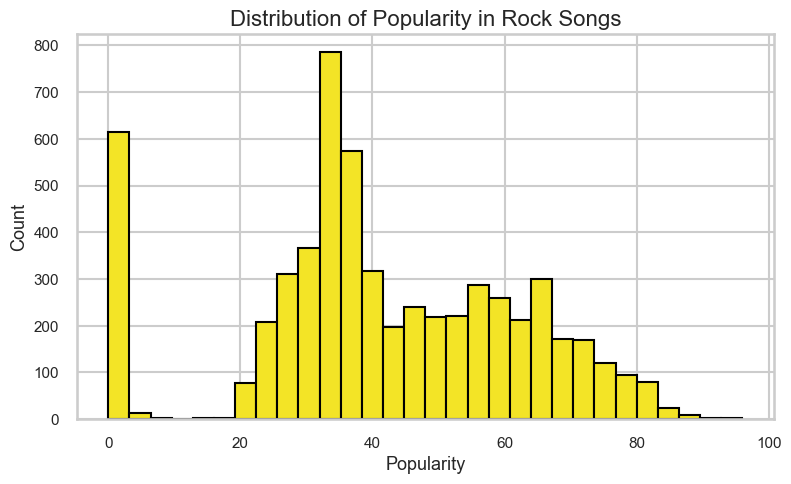

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(rock_df["popularity"], bins=30, color="#f3e426", edgecolor="black")
plt.title("Distribution of Popularity in Rock Songs")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

### Interpretation

The popularity scores are concentrated mostly in the middle range, with many songs falling roughly between 20 and 40.  
Very low-popularity and very high-popularity songs are less common, suggesting that the dataset is dominated by moderately popular rock tracks rather than extreme outliers.

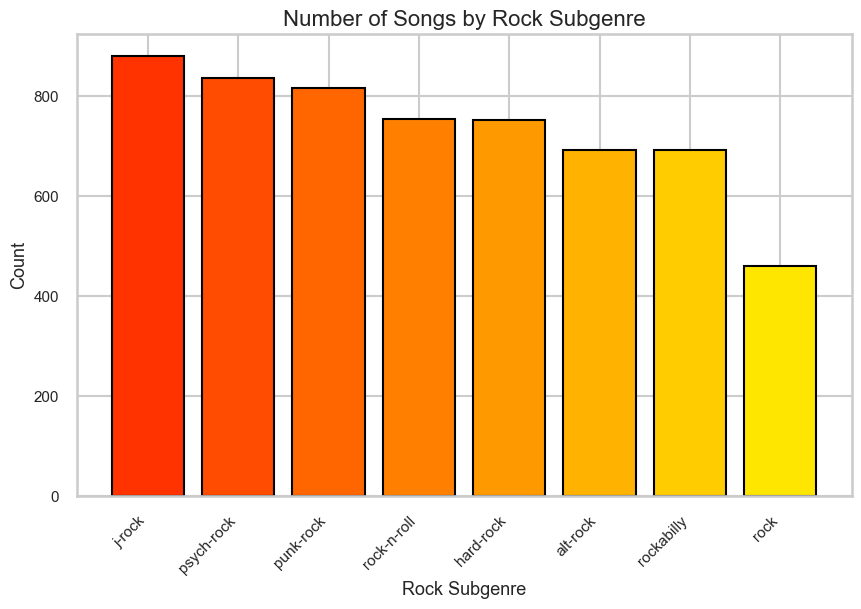

In [6]:
subgenre_counts = rock_df["track_genre"].value_counts()

colors = plt.cm.autumn(np.linspace(0.2, 0.9, len(subgenre_counts)))

plt.figure(figsize=(10, 6))
plt.bar(subgenre_counts.index, subgenre_counts.values, color=colors, edgecolor="black")
plt.title("Number of Songs by Rock Subgenre")
plt.xlabel("Rock Subgenre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

### Interpretation

The cleaned dataset remains reasonably balanced across subgenres, although duplicate removal reduced some categories more than others.  
This is still a strong structure for comparative analysis, since no subgenre has become too small to analyze meaningfully.

C:\Users\Pc\AppData\Local\Temp\ipykernel_76244\402520511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=rock_df, x="track_genre", y="popularity", palette="flare")


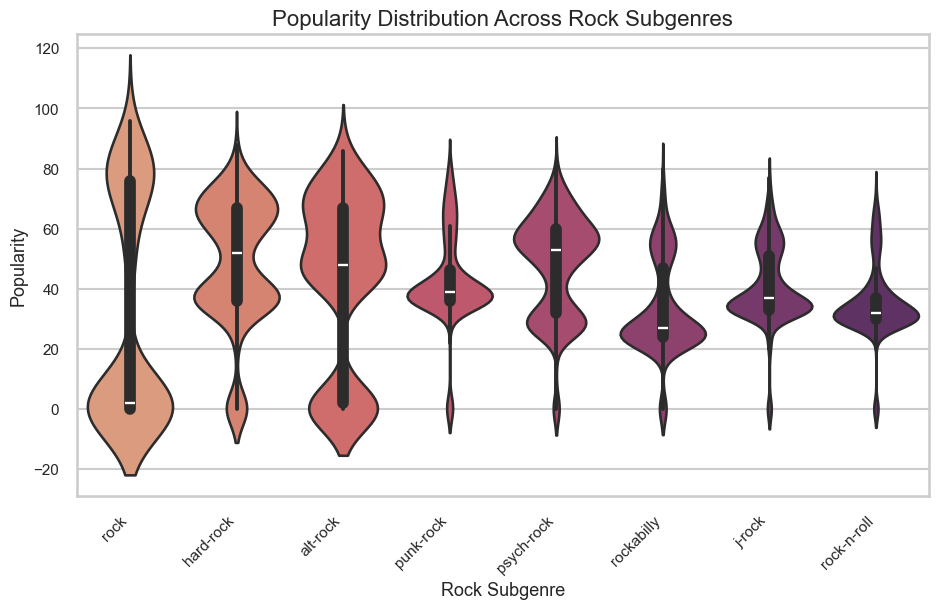

In [7]:
plt.figure(figsize=(11, 6))
sns.violinplot(data=rock_df, x="track_genre", y="popularity", palette="flare")
plt.title("Popularity Distribution Across Rock Subgenres")
plt.xlabel("Rock Subgenre")
plt.ylabel("Popularity")
plt.xticks(rotation=45, ha="right")
plt.show()

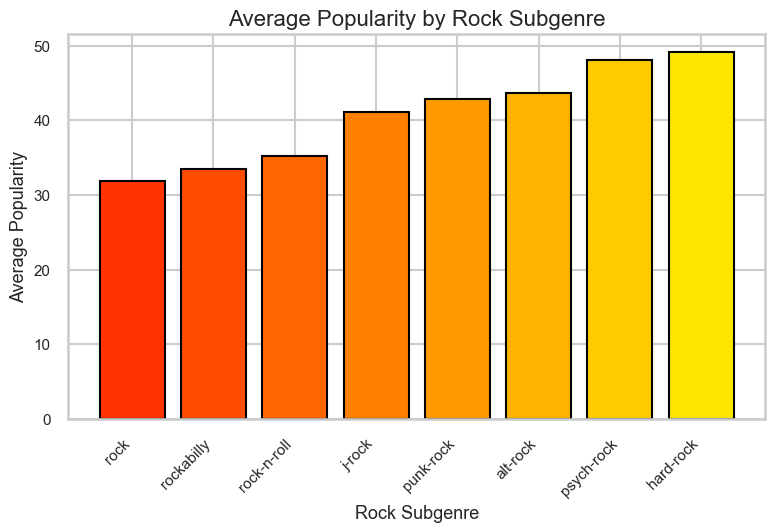

In [8]:
subgenre_popularity = rock_df.groupby("track_genre")["popularity"].mean().sort_values()
colors = plt.cm.autumn(np.linspace(0.2, 0.9, len(subgenre_popularity)))

plt.figure(figsize=(9, 5))
plt.bar(subgenre_popularity.index, subgenre_popularity.values, color=colors, edgecolor="black")
plt.title("Average Popularity by Rock Subgenre")
plt.xlabel("Rock Subgenre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45, ha="right")
plt.show()

### Interpretation

The rock subgenres do not appear to have identical popularity distributions.  
Some subgenres seem to have higher average popularity than others, while some show wider spreads and greater variability.  

This suggests that subgenre may play a role in shaping popularity and should be treated as an important grouping variable in later hypothesis tests.

----------------------------------------------------

## Distribution of Main Audio Features

Before comparing hits and subgenres in detail, it is useful to inspect the overall distributions of key Spotify audio features.

This helps describe the musical profile of the rock subset as a whole and shows whether features tend to cluster in narrow or wide ranges.

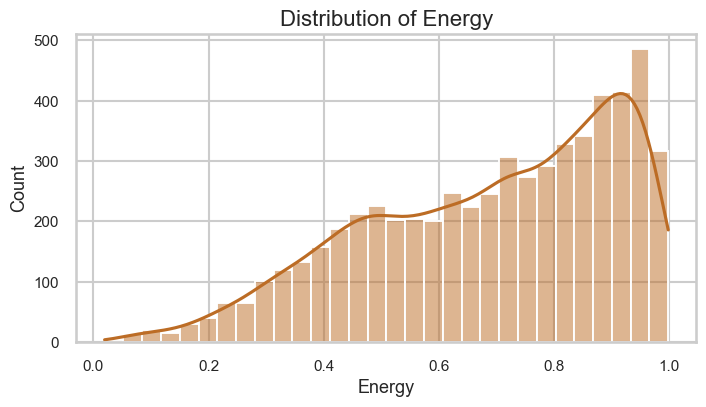

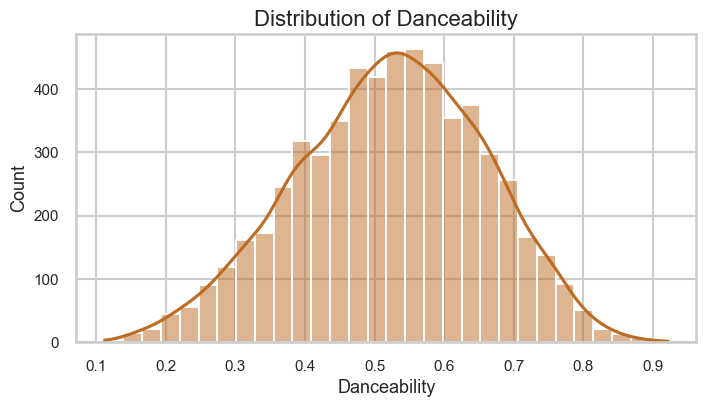

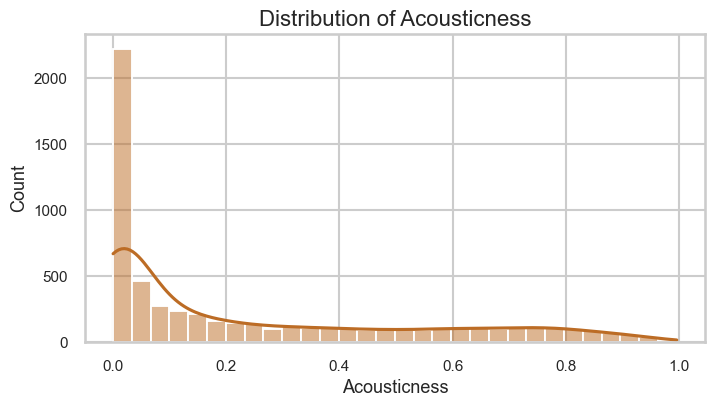

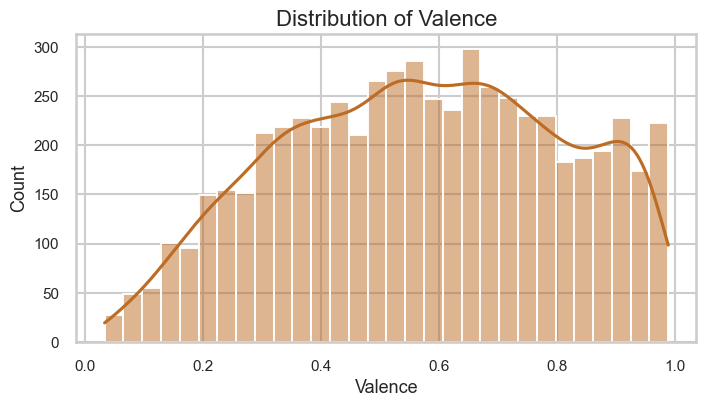

In [9]:
features = ["energy", "danceability", "acousticness", "valence"]

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=rock_df, x=feature, bins=30, kde=True, color="#BC6C25")
    plt.title(f"Distribution of {feature.capitalize()}")
    plt.xlabel(feature.capitalize())
    plt.ylabel("Count")
    plt.show()

### Interpretation

These distributions show that the rock dataset is not uniform across audio features.  
Some features appear concentrated within relatively narrow ranges, while others are spread more broadly across songs.  

This variation is useful because it means the dataset has enough diversity for both subgenre comparisons and popularity-based analysis.

---------------------------------------

## Average Audio Profiles by Subgenre

This section compares average audio-feature values across rock subgenres.

Rather than looking at only one feature at a time, a feature heatmap provides a compact way to compare the musical profiles of the subgenres.

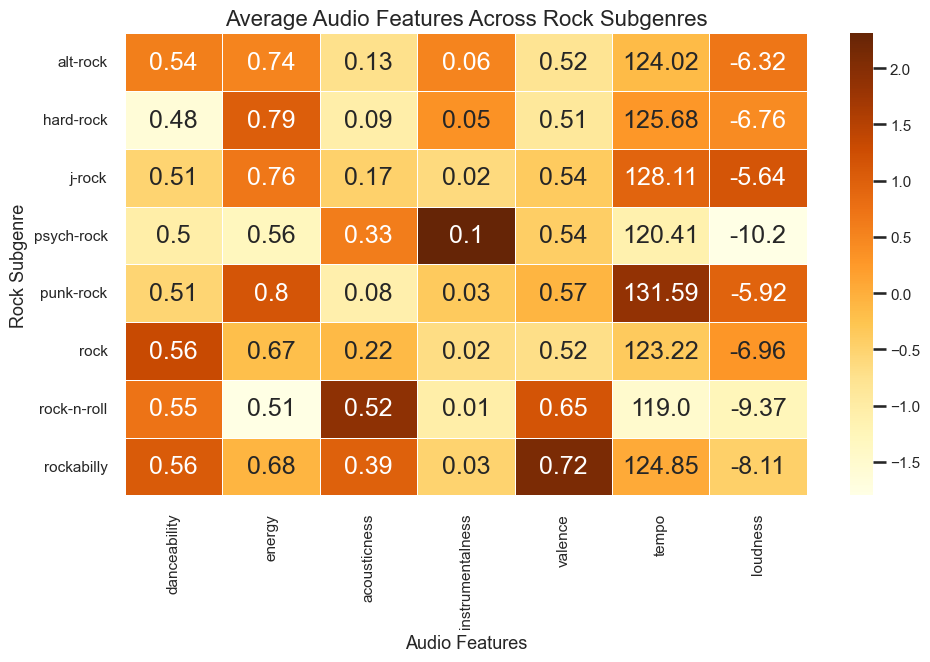

In [14]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "valence",
    "tempo",
    "loudness"
]

subgenre_feature_means = rock_df.groupby("track_genre")[feature_cols].mean()

scaler = StandardScaler()
scaled_means = pd.DataFrame(
    scaler.fit_transform(subgenre_feature_means),
    index=subgenre_feature_means.index,
    columns=subgenre_feature_means.columns
)

plt.figure(figsize=(11, 6))
sns.heatmap(scaled_means, annot=subgenre_feature_means.round(2), cmap="YlOrBr", fmt="", linewidths=0.5)
plt.title("Average Audio Features Across Rock Subgenres")
plt.xlabel("Audio Features")
plt.ylabel("Rock Subgenre")
plt.show()

### Interpretation

The subgenres appear to differ meaningfully in their average audio profiles.  
This supports the idea that rock subgenres are not only distinct by label, but also distinguishable through measurable Spotify audio features.

This is important for the project because it suggests that subgenre-level structure is real and may help explain popularity differences.

-----------------

## Correlation Between Popularity and Audio Features

This section examines pairwise linear correlations among popularity and key numerical audio variables.

The goal here is exploratory rather than inferential: the heatmap is used to identify whether any variables appear promising for later testing and modeling.

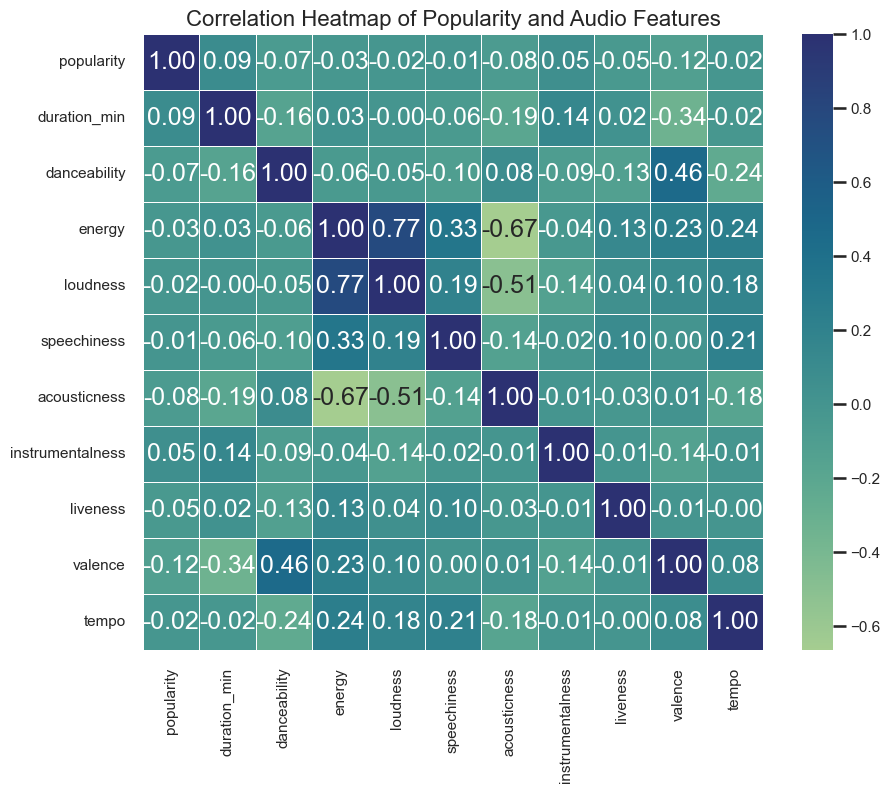

In [18]:
audio_cols = [
    "popularity",
    "duration_min",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

plt.figure(figsize=(10, 8))
sns.heatmap(rock_df[audio_cols].corr(), cmap="crest", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Popularity and Audio Features")
plt.show()

### Interpretation

The correlation matrix suggests that popularity does not have strong linear relationships with most individual audio features.  
This implies that hit status may not be driven by a single dominant feature, but instead may depend on more subtle combinations of variables.

Among the features examined, some may still be worth testing further even if their correlations are weak.

-----------------------------

## Hit vs Non-Hit Songs

This section compares songs labeled as hits and non-hits based on the popularity threshold defined in the cleaning notebook.

The purpose is to check whether hit songs show visibly different audio patterns from non-hit songs.

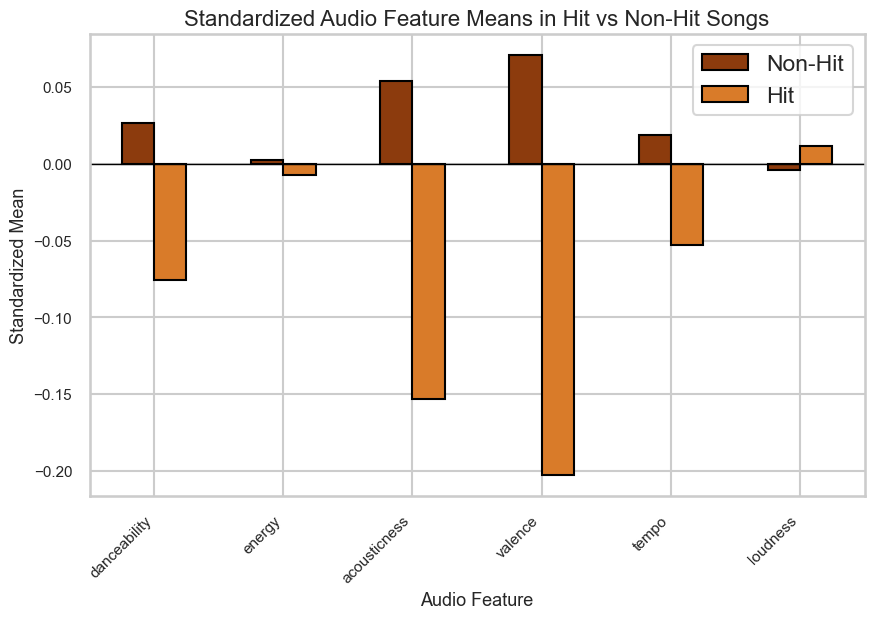

In [24]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

compare_cols = ["danceability", "energy", "acousticness", "valence", "tempo", "loudness"]

scaled_df = rock_df.copy()
scaled_df[compare_cols] = StandardScaler().fit_transform(rock_df[compare_cols])

hit_feature_means = scaled_df.groupby("is_hit")[compare_cols].mean().T
hit_feature_means.columns = ["Non-Hit", "Hit"]

colors = ["#8C3B0D", "#D97B29"]

hit_feature_means.plot(kind="bar", figsize=(10, 6), color=colors, edgecolor="black")
plt.title("Standardized Audio Feature Means in Hit vs Non-Hit Songs")
plt.ylabel("Standardized Mean")
plt.xlabel("Audio Feature")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=1)
plt.show()

C:\Users\Pc\AppData\Local\Temp\ipykernel_76244\2202843320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rock_df, x="is_hit", y=feature, palette="flare")


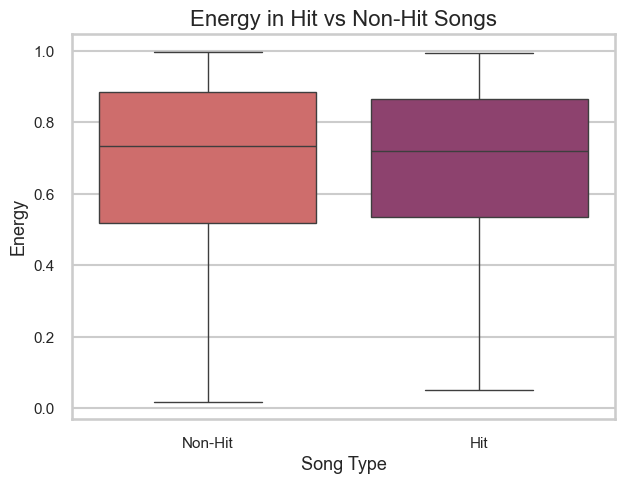

C:\Users\Pc\AppData\Local\Temp\ipykernel_76244\2202843320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rock_df, x="is_hit", y=feature, palette="flare")


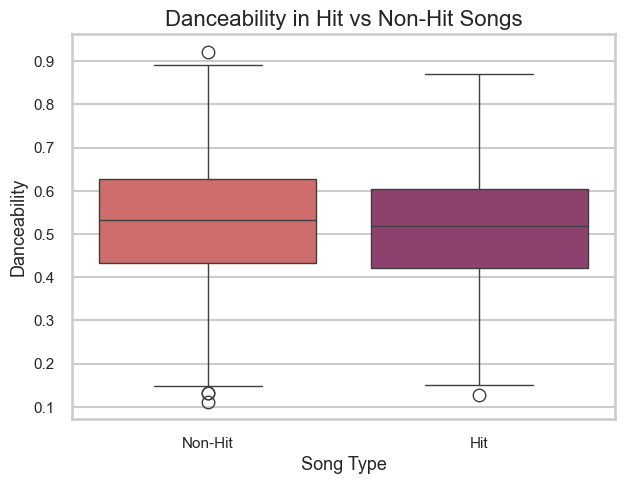

C:\Users\Pc\AppData\Local\Temp\ipykernel_76244\2202843320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rock_df, x="is_hit", y=feature, palette="flare")


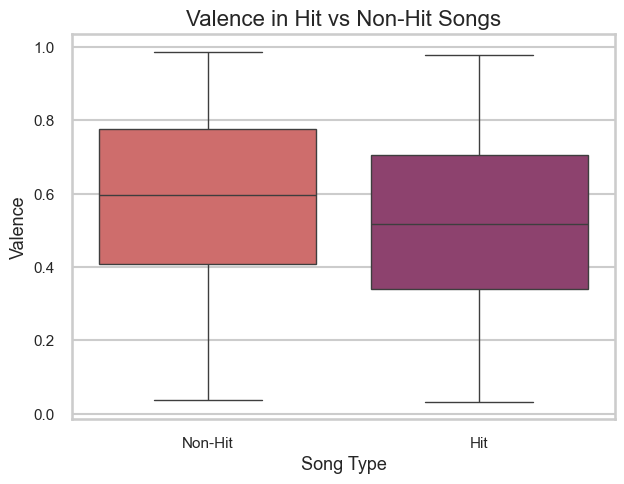

C:\Users\Pc\AppData\Local\Temp\ipykernel_76244\2202843320.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rock_df, x="is_hit", y=feature, palette="flare")


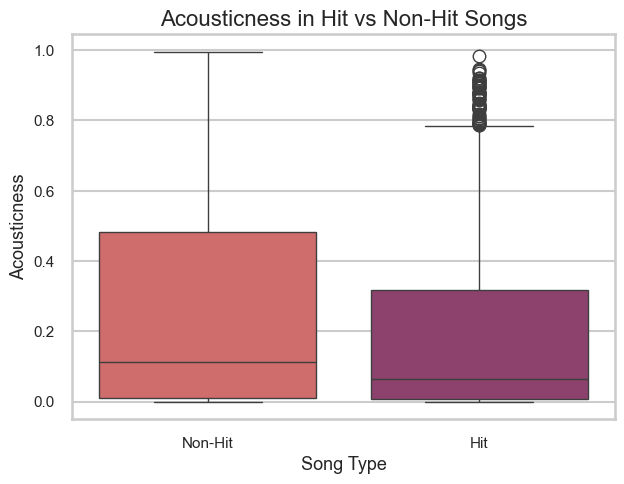

In [25]:
for feature in ["energy", "danceability", "valence", "acousticness"]:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=rock_df, x="is_hit", y=feature, palette="flare")
    plt.xticks([0, 1], ["Non-Hit", "Hit"])
    plt.title(f"{feature.capitalize()} in Hit vs Non-Hit Songs")
    plt.xlabel("Song Type")
    plt.ylabel(feature.capitalize())
    plt.show()

### Interpretation

Hit and non-hit songs appear broadly similar across several audio features, especially energy, danceability, and valence.  
This suggests that many commonly used audio features may not sharply separate successful songs from less successful ones in the rock subset.

However, acousticness appears to show somewhat clearer separation than the other variables, making it a promising candidate for formal hypothesis testing.

-------------------------

## Feature-Level Relationships with Popularity

To complement the correlation matrix, this section visualizes the relationship between popularity and a few selected candidate features.

Scatterplots are useful here because they can reveal dispersion, clusters, or weak trends that may not be obvious from correlations alone.

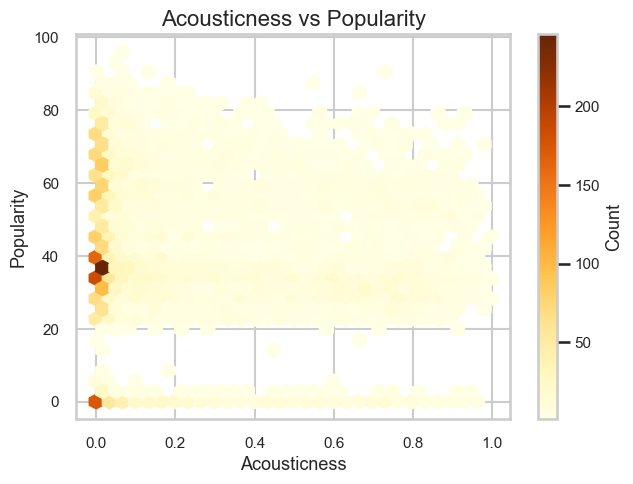

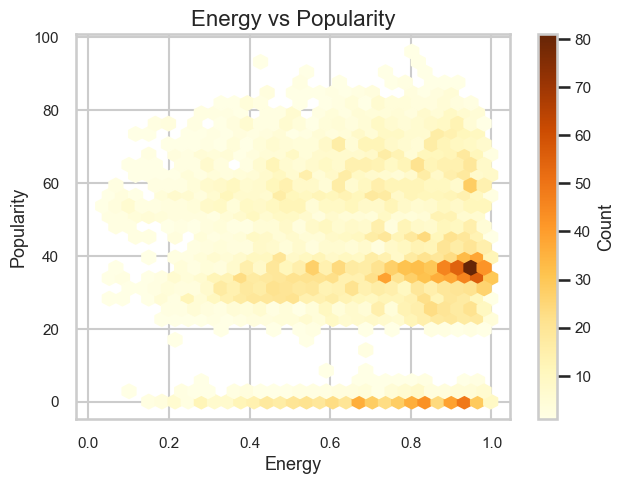

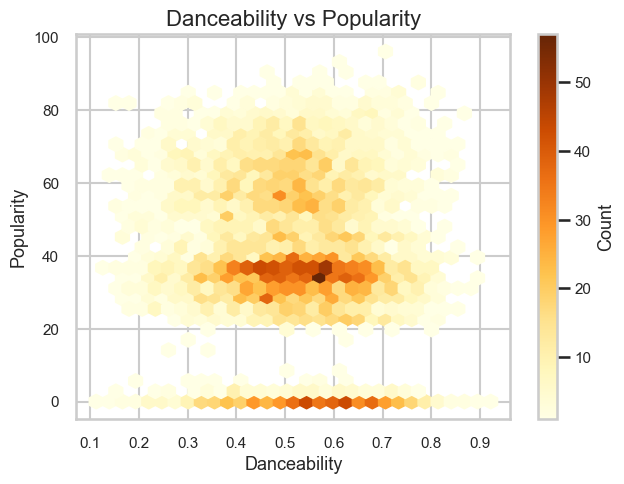

In [29]:
for feature in ["acousticness", "energy", "danceability"]:
    plt.figure(figsize=(7, 5))
    plt.hexbin(
        rock_df[feature],
        rock_df["popularity"],
        gridsize=30,
        cmap="YlOrBr",
        mincnt=1
    )
    plt.colorbar(label="Count")
    plt.title(f"{feature.capitalize()} vs Popularity")
    plt.xlabel(feature.capitalize())
    plt.ylabel("Popularity")
    plt.show()

Because the dataset contains several thousand songs and popularity values are discrete, direct scatterplots can become visually crowded. To make density patterns easier to interpret, hexbin plots are used to show how observations are concentrated across the feature-popularity space.

-------------------------

## Artist Presence in the Dataset

As a final descriptive step, it is useful to inspect which artists appear most often in the cleaned rock subset.

This does not directly test a project hypothesis, but it helps describe the composition of the dataset and adds context to the analysis.

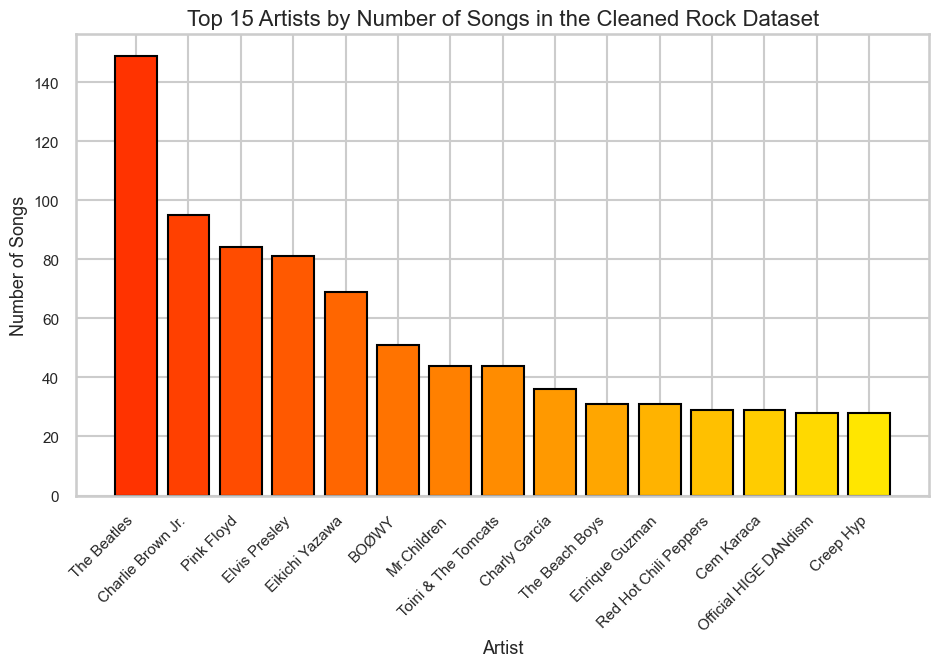

In [30]:
top_artists = rock_df["artists"].value_counts().head(15)
colors = plt.cm.autumn(np.linspace(0.2, 0.9, len(top_artists)))

plt.figure(figsize=(11, 6))
plt.bar(top_artists.index, top_artists.values, color=colors, edgecolor="black")
plt.title("Top 15 Artists by Number of Songs in the Cleaned Rock Dataset")
plt.xlabel("Artist")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45, ha="right")
plt.show()

### Interpretation

A small number of artists appear multiple times in the cleaned dataset, which is expected in a large music dataset built from Spotify tracks.  
This confirms that the dataset contains repeated artist presence across subgenres, while still maintaining enough variation for broader song-level analysis.

## EDA Summary

The exploratory analysis shows that popularity in the rock subset is concentrated mostly in the middle range rather than at the extremes.  
Rock subgenres differ in both their popularity distributions and their average audio-feature profiles, suggesting that subgenre is a meaningful structural factor in the dataset.  

At the same time, most individual audio features appear to have only weak direct relationships with popularity.  
Among the examined variables, acousticness appears to be one of the more promising candidates for distinguishing hit and non-hit songs.

These findings motivate the next stage of the project: formal hypothesis testing on subgenre differences and feature-popularity relationships.